Spectra shape: (13, 7468)
Predictions: [0.68264792 0.75094604 0.72988301 1.13861429 1.03121299 1.12521589
 0.39536585 0.48405949 0.59313565 0.30755702 0.65629149 0.72045835
 0.7332359 ]


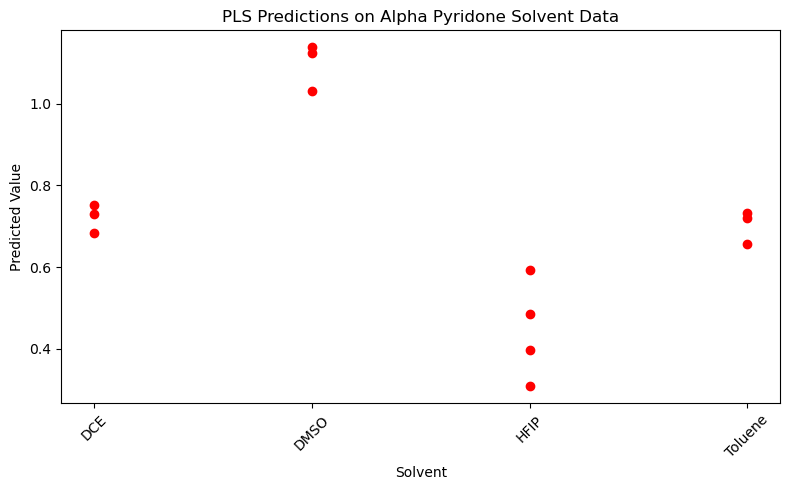

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

columns = ['y'] + [f'x{i+1}' for i in range(len(x_column))]
final_df = pd.DataFrame(rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components);
pls.fit(X, y)


#second bunch
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_001/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:13]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 4 +
    ['Toluene'] * 3
)
assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []
for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")

spectra_df = pd.DataFrame(spectra, columns=[f'x{i+1}' for i in range(spectra.shape[1])])
y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

#y_pred_clipped = np.clip(y_pred, 0, 1)
#print("Predictions:", y_pred_clipped)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on Alpha Pyridone Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Spectra shape: (12, 7468)
Predictions: [0.67359622 0.75963484 0.76094364 1.04960103 0.89482539 1.10931629
 0.30808198 0.27385977 0.19182824 0.66214956 0.67351546 0.7446845 ]


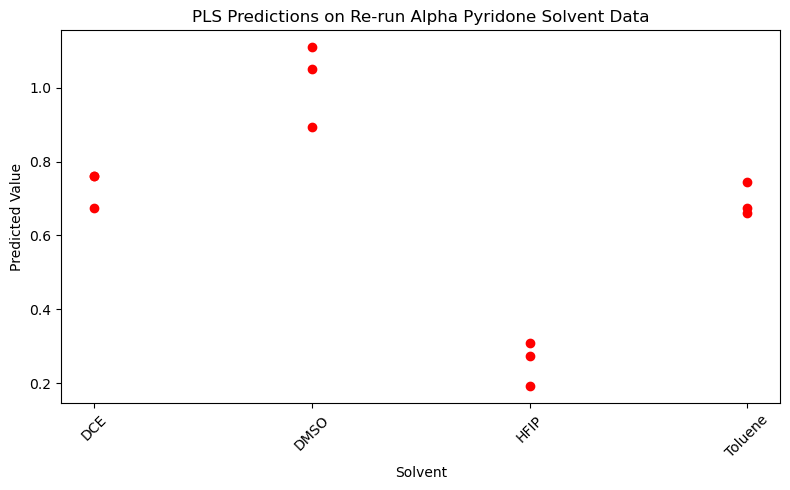

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

columns = ['y'] + [f'x{i+1}' for i in range(len(x_column))]
final_df = pd.DataFrame(rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components);
pls.fit(X, y)


#second bunch
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_004/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:13]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 3 +
    ['Toluene'] * 3
)
assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []
for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")

spectra_df = pd.DataFrame(spectra, columns=[f'x{i+1}' for i in range(spectra.shape[1])])
y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

#y_pred_clipped = np.clip(y_pred, 0, 1)
#print("Predictions:", y_pred_clipped)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on Re-run Alpha Pyridone Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Spectra shape: (12, 7468)
Predictions: [0.67359622 0.75963484 0.76094364 1.04960103 0.89482539 1.10931629
 0.30808198 0.27385977 0.19182824 0.66214956 0.67351546 0.7446845 ]

Average Prediction per Solvent:
Solvent
DCE        0.731392
DMSO       1.017914
HFIP       0.257923
Toluene    0.693450
Name: Prediction, dtype: float64

Comparison to True Value (0.75):
         Avg Prediction  True Value     Error  Abs Error
Solvent                                                 
DCE            0.731392         0.8 -0.068608   0.068608
DMSO           1.017914         0.8  0.217914   0.217914
HFIP           0.257923         0.8 -0.542077   0.542077
Toluene        0.693450         0.8 -0.106550   0.106550

MAE vs true value: 0.2337873749343989


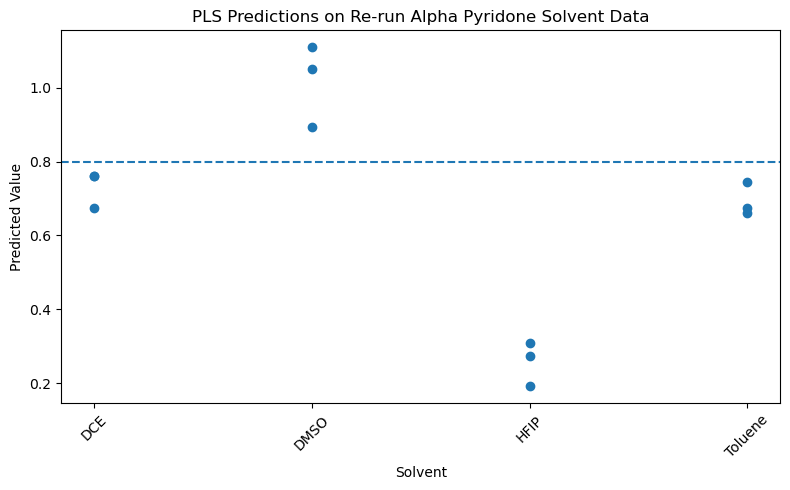

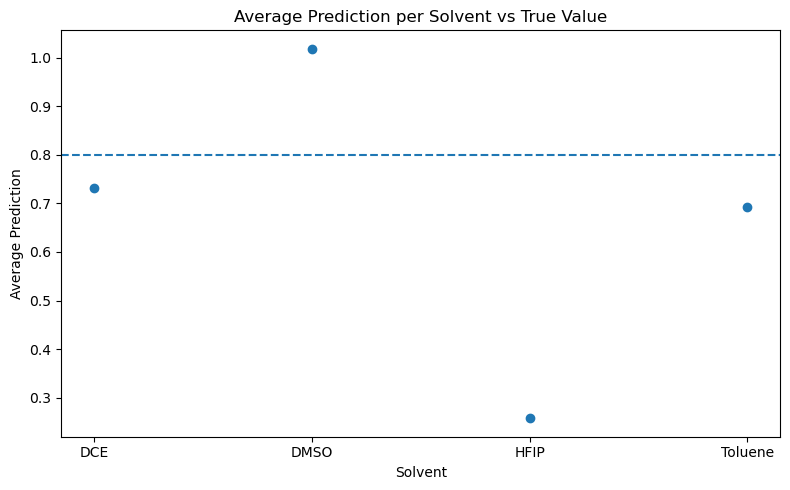

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

columns = ['y'] + [f'x{i+1}' for i in range(len(x_column))]
final_df = pd.DataFrame(rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)


# second dataset (predictions)
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_004/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DCE'] * 3 +
    ['DMSO'] * 3 +
    ['HFIP'] * 3 +
    ['Toluene'] * 3
)

assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []

for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")

spectra_df = pd.DataFrame(
    spectra,
    columns=[f'x{i+1}' for i in range(spectra.shape[1])]
)

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

# Averaging predictions

true_value = 0.8

results_df = pd.DataFrame({
    'Solvent': solvent_labels,
    'Prediction': y_pred
})

avg_predictions = results_df.groupby('Solvent')['Prediction'].mean()

print("\nAverage Prediction per Solvent:")
print(avg_predictions)

# MAE calculation

comparison = pd.DataFrame({
    'Avg Prediction': avg_predictions,
    'True Value': true_value,
    'Error': avg_predictions - true_value,
    'Abs Error': abs(avg_predictions - true_value)
})

print("\nComparison to True Value (0.75):")
print(comparison)

mae = np.mean(np.abs(avg_predictions - true_value))
print("\nMAE vs true value:", mae)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on Re-run Alpha Pyridone Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(avg_predictions.index, avg_predictions.values)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Average Prediction')
plt.title('Average Prediction per Solvent vs True Value')
plt.tight_layout()
plt.show()

Prediction for YH_2025_012_DEE_A.CSV: y = 0.2058, MAE = 0.594157
Prediction for YH_2025_012_DEE_B.CSV: y = 0.2309, MAE = 0.569081
Prediction for YH_2025_012_DEE_C.CSV: y = 0.2784, MAE = 0.521614
Prediction for YH_2025_012_DMSO_A.CSV: y = 0.2092, MAE = 0.590805
Prediction for YH_2025_012_DMSO_B.CSV: y = 0.4269, MAE = 0.373110
Prediction for YH_2025_012_DMSO_C.CSV: y = 0.3585, MAE = 0.441519
Prediction for YH_2025_012_IPA_A(real).CSV: y = 0.7094, MAE = 0.090610
Prediction for YH_2025_012_IPA_B(real).CSV: y = 0.8076, MAE = 0.007576
Prediction for YH_2025_012_IPA_C(real).CSV: y = 0.8369, MAE = 0.036926
Prediction for YH_2025_012_Water_A.CSV: y = 1.3671, MAE = 0.567135
Prediction for YH_2025_012_Water_B.CSV: y = 1.3507, MAE = 0.550653
Prediction for YH_2025_012_Water_C.CSV: y = 0.9573, MAE = 0.157338

Average MAE across all test files: 0.3750

Full results saved to original_calibration_test_results.csv


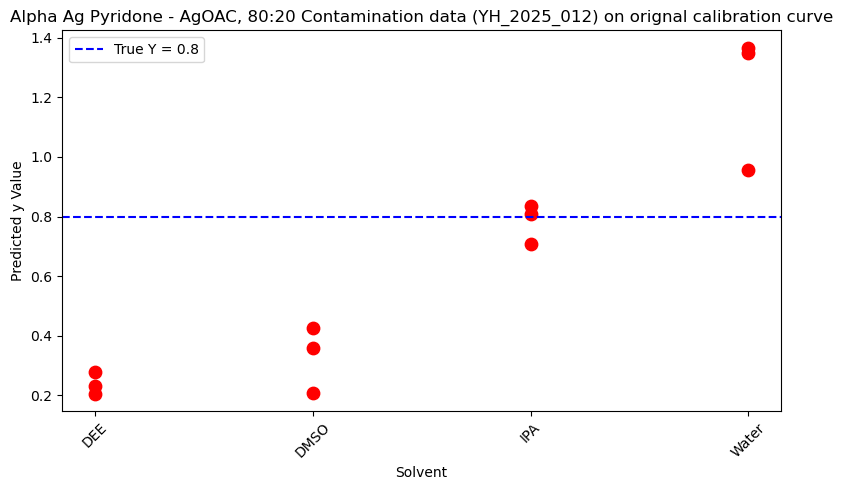

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'
test_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

files = sorted([f for f in os.listdir(root_directory) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]
if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []
for file, y_val in zip(files, y_values):
    data = pd.read_csv(os.path.join(root_directory, file), header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_val)
    rows.append(row)

min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X_calib, y_calib)

test_files = sorted([f for f in os.listdir(test_directory) if f.lower().endswith('.csv')])[:12]

spectra = []
for file2 in test_files:
    data2 = pd.read_csv(os.path.join(test_directory, file2), header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2[:min_len-1])  # trim to match calibration

spectra_df = pd.DataFrame(spectra, columns=[f'x{i+1}' for i in range(min_len-1)])

y_pred = pls.predict(spectra_df.values).ravel()
true_y = 0.8  

mae_list = []
results = []

for file, pred in zip(test_files, y_pred):
    mae = mean_absolute_error([true_y], [pred])
    mae_list.append(mae)
    results.append({'test_file': file, 'y_pred': pred, 'true_y': true_y, 'mae': mae})
    print(f"Prediction for {file}: y = {pred:.4f}, MAE = {mae:.6f}")

average_mae = np.mean(mae_list)
print(f"\nAverage MAE across all test files: {average_mae:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('original_calibration_test_results.csv', index=False)
print("\nFull results saved to original_calibration_test_results.csv")

solvent_labels = (
    ['DEE'] * 3 + ['DMSO'] * 3 + ['IPA'] * 3 + ['Water'] * 3
)
plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red', s=80)
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True Y = {true_y}')
plt.xticks(rotation=45)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Alpha Ag Pyridone - AgOAC, 80:20 Contamination data (YH_2025_012) on orignal calibration curve')
plt.legend()
plt.tight_layout()
plt.show()

                    test_file  y_pred  true_y     MAE
1       YH_2025_004_DCE_A.CSV  0.6736     0.8  0.1264
2       YH_2025_004_DCE_B.CSV  0.7596     0.8  0.0404
3       YH_2025_004_DCE_C.CSV  0.7609     0.8  0.0391
4      YH_2025_004_DMSO_A.CSV  1.0496     0.8  0.2496
5      YH_2025_004_DMSO_B.CSV  0.8948     0.8  0.0948
6      YH_2025_004_DMSO_C.CSV  1.1093     0.8  0.3093
7      YH_2025_004_HFIP_A.CSV  0.3081     0.8  0.4919
8      YH_2025_004_HFIP_B.CSV  0.2739     0.8  0.5261
9      YH_2025_004_HFIP_C.CSV  0.1918     0.8  0.6082
10  YH_2025_004_Toluene_A.CSV  0.6621     0.8  0.1379
11  YH_2025_004_Toluene_B.CSV  0.6735     0.8  0.1265
12  YH_2025_004_Toluene_C.CSV  0.7447     0.8  0.0553

Average MAE across all test files: 0.2338


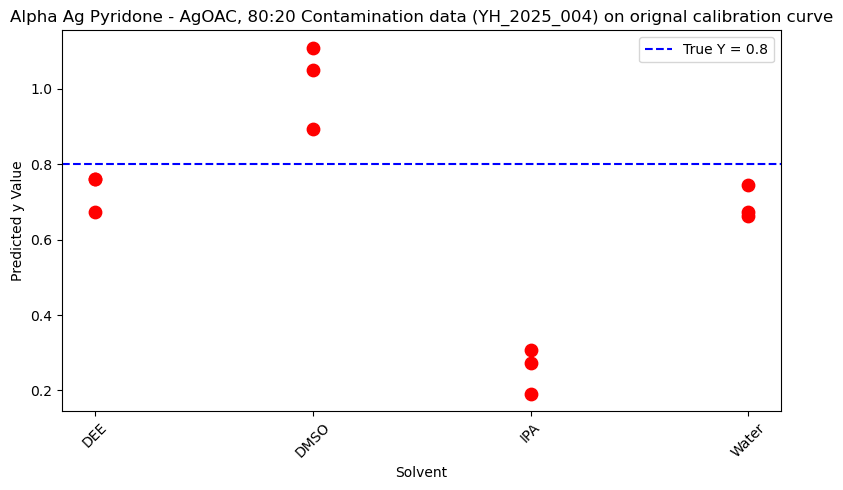

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'
test_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_004/'

files = sorted([f for f in os.listdir(root_directory) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]
if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []
for file, y_val in zip(files, y_values):
    data = pd.read_csv(os.path.join(root_directory, file), header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_val)
    rows.append(row)

min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X_calib, y_calib)

test_files = sorted([f for f in os.listdir(test_directory) if f.lower().endswith('.csv')])[:12]

spectra = []
for file2 in test_files:
    data2 = pd.read_csv(os.path.join(test_directory, file2), header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2[:min_len-1])  # trim to match calibration

spectra_df = pd.DataFrame(spectra, columns=[f'x{i+1}' for i in range(min_len-1)])

y_pred = pls.predict(spectra_df.values).ravel()
true_y = 0.8  

mae_list = []
results = []

for file, pred in zip(test_files, y_pred):
    mae = mean_absolute_error([true_y], [pred])
    mae_list.append(mae)
    results.append({'test_file': file, 'y_pred': pred, 'true_y': true_y, 'MAE': mae})

results_df = pd.DataFrame(results)
results_df.index = results_df.index + 1
results_df[['y_pred', 'true_y', 'MAE']] = (results_df[['y_pred', 'true_y', 'MAE']].round(4))
print(results_df)
average_mae = np.mean(mae_list)
print(f"\nAverage MAE across all test files: {average_mae:.4f}")

solvent_labels = (
    ['DEE'] * 3 + ['DMSO'] * 3 + ['IPA'] * 3 + ['Water'] * 3
)
plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred, color='red', s=80)
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True Y = {true_y}')
plt.xticks(rotation=45)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Alpha Ag Pyridone - AgOAC, 80:20 Contamination data (YH_2025_004) on orignal calibration curve')
plt.legend()
plt.tight_layout()
plt.show()

Spectra shape: (12, 7468)
Predictions: [0.2058434  0.23091896 0.27838643 0.20919532 0.42688997 0.35848087
 0.70939043 0.80757631 0.83692557 1.36713549 1.35065273 0.95733771]

Average Prediction per Solvent:
Solvent
DEE      0.238383
DMSO     0.331522
IPA      0.784631
Water    1.225042
Name: Prediction, dtype: float64

Comparison to True Value (0.75):
         Avg Prediction  True Value     Error  Abs Error
Solvent                                                 
DEE            0.238383         0.8 -0.561617   0.561617
DMSO           0.331522         0.8 -0.468478   0.468478
IPA            0.784631         0.8 -0.015369   0.015369
Water          1.225042         0.8  0.425042   0.425042

MAE vs true value: 0.3676265561485731


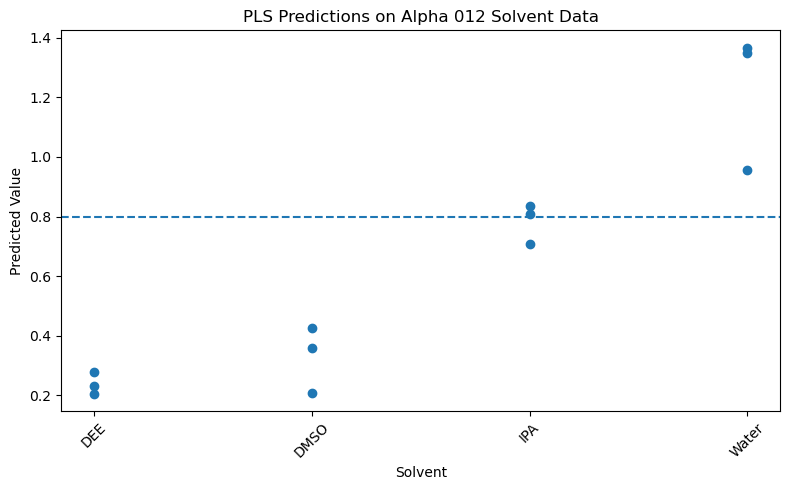

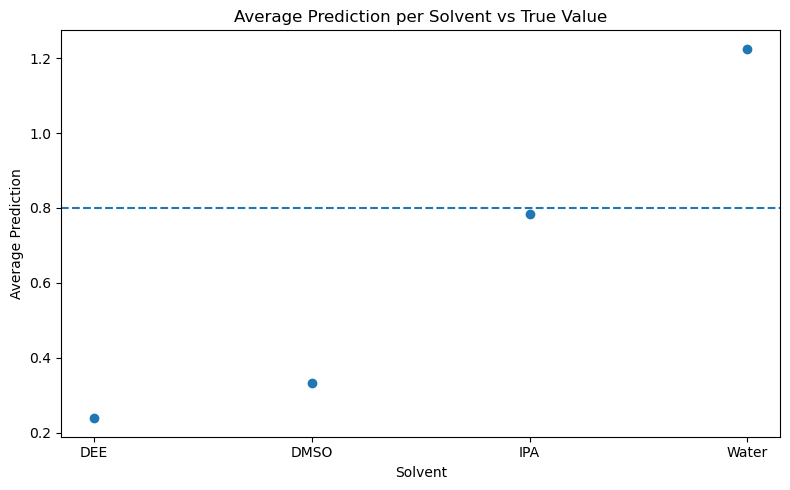

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)
min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]

n_components = 5
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)


# second dataset (predictions)
root_directory2 = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

files2 = [file2 for file2 in os.listdir(root_directory2) if file2.lower().endswith('.csv')]
files2.sort()
files2 = files2[:12]

solvent_labels = (
    ['DEE'] * 3 +
    ['DMSO'] * 3 +
    ['IPA'] * 3 +
    ['Water'] * 3
)

assert len(solvent_labels) == len(files2), "Solvent labels count mismatch with files!"

spectra = []

for file2 in files2:
    file_path2 = os.path.join(root_directory2, file2)
    data2 = pd.read_csv(file_path2, header=None, skiprows=1)
    x_column2 = data2.iloc[:, 1].values
    spectra.append(x_column2)

spectra = np.array(spectra)
print(f"Spectra shape: {spectra.shape}")


spectra_trimmed = [s[:min_len - 1] for s in spectra]

spectra_df = pd.DataFrame(spectra_trimmed,
                          columns=[f'x{i+1}' for i in range(min_len - 1)])

y_pred = pls.predict(spectra_df).ravel()
print("Predictions:", y_pred)

# Averaging predictions

true_value = 0.8

results_df = pd.DataFrame({
    'Solvent': solvent_labels,
    'Prediction': y_pred
})

avg_predictions = results_df.groupby('Solvent')['Prediction'].mean()

print("\nAverage Prediction per Solvent:")
print(avg_predictions)

# MAE calculation

comparison = pd.DataFrame({
    'Avg Prediction': avg_predictions,
    'True Value': true_value,
    'Error': avg_predictions - true_value,
    'Abs Error': abs(avg_predictions - true_value)
})

print("\nComparison to True Value (0.75):")
print(comparison)

mae = np.mean(np.abs(avg_predictions - true_value))
print("\nMAE vs true value:", mae)

plt.figure(figsize=(8, 5))
plt.scatter(solvent_labels, y_pred)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('PLS Predictions on Alpha 012 Solvent Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(avg_predictions.index, avg_predictions.values)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Average Prediction')
plt.title('Average Prediction per Solvent vs True Value')
plt.tight_layout()
plt.show()